# Metals Cross-Sectional Flow Anomaly Research Framework

Universe: `GC`, `SI`, `HG`, `PL`, `PA`, `ALI`.

This notebook inspects synchronized cross-sectional dollar bars, contribution geometry, Mahalanobis flow anomalies, trade-size flow disagreement, relative-value residuals, cointegration diagnostics, forward-return studies, and momentum-versus-mean-reversion classification.

The heavy pipeline writes artifacts under `experiments/HYP-0012-metals-flow-anomaly-framework`. The notebook loads those artifacts and only reruns the pipeline if `results.json` is missing.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from quantlab.metals_flow.config import MetalsFlowConfig
from quantlab.metals_flow.runner import run_metals_flow_research

CONFIG_PATH = Path("../../experiments/HYP-0012-metals-flow-anomaly-framework/config.yaml").resolve()
config = MetalsFlowConfig.from_yaml(CONFIG_PATH)
OUT = config.output_dir
RESULTS = OUT / "results.json"

if not RESULTS.exists():
    run_metals_flow_research(config)

results = json.loads(RESULTS.read_text())
summary = results["summary"]
artifacts = {key: Path(value) for key, value in results["artifacts"].items()}
summary.keys()

dict_keys(['anomaly_counts', 'cointegration_pairs_p_lt_0_05', 'dominant_share', 'end', 'geometry_skipped', 'mbp1_availability', 'md_rolling_quantiles', 'mean_contribution', 'mechanism_counts', 'primary_complete_bars', 'primary_threshold', 'roots', 'start', 'threshold_summary', 'top_forward_buckets', 'top_information_coefficients', 'trade_rows'])

## Data Coverage And Bar Sensitivity

In [2]:
threshold_summary = pd.read_csv(OUT / "threshold_summary.csv")
threshold_summary

,threshold,threshold_m,bars,bars_per_day,median_duration_seconds,mean_duration_seconds,median_trades,mean_trades,median_dominant_share,mean_hhi
0,1.000000e+08,100.0,15465,550.699710,73.160170,156.464352,213.0,212.884061,0.752341,0.610543
1,2.500000e+08,250.0,6204,220.941231,192.903512,390.612725,531.0,530.614765,0.745081,0.598933
2,5.000000e+08,500.0,3105,110.594984,396.984872,780.761148,1061.0,1060.093720,0.740850,0.592693
3,1.000000e+09,1000.0,1553,55.327812,818.145684,1561.223228,2116.0,2119.144237,0.738770,0.587274


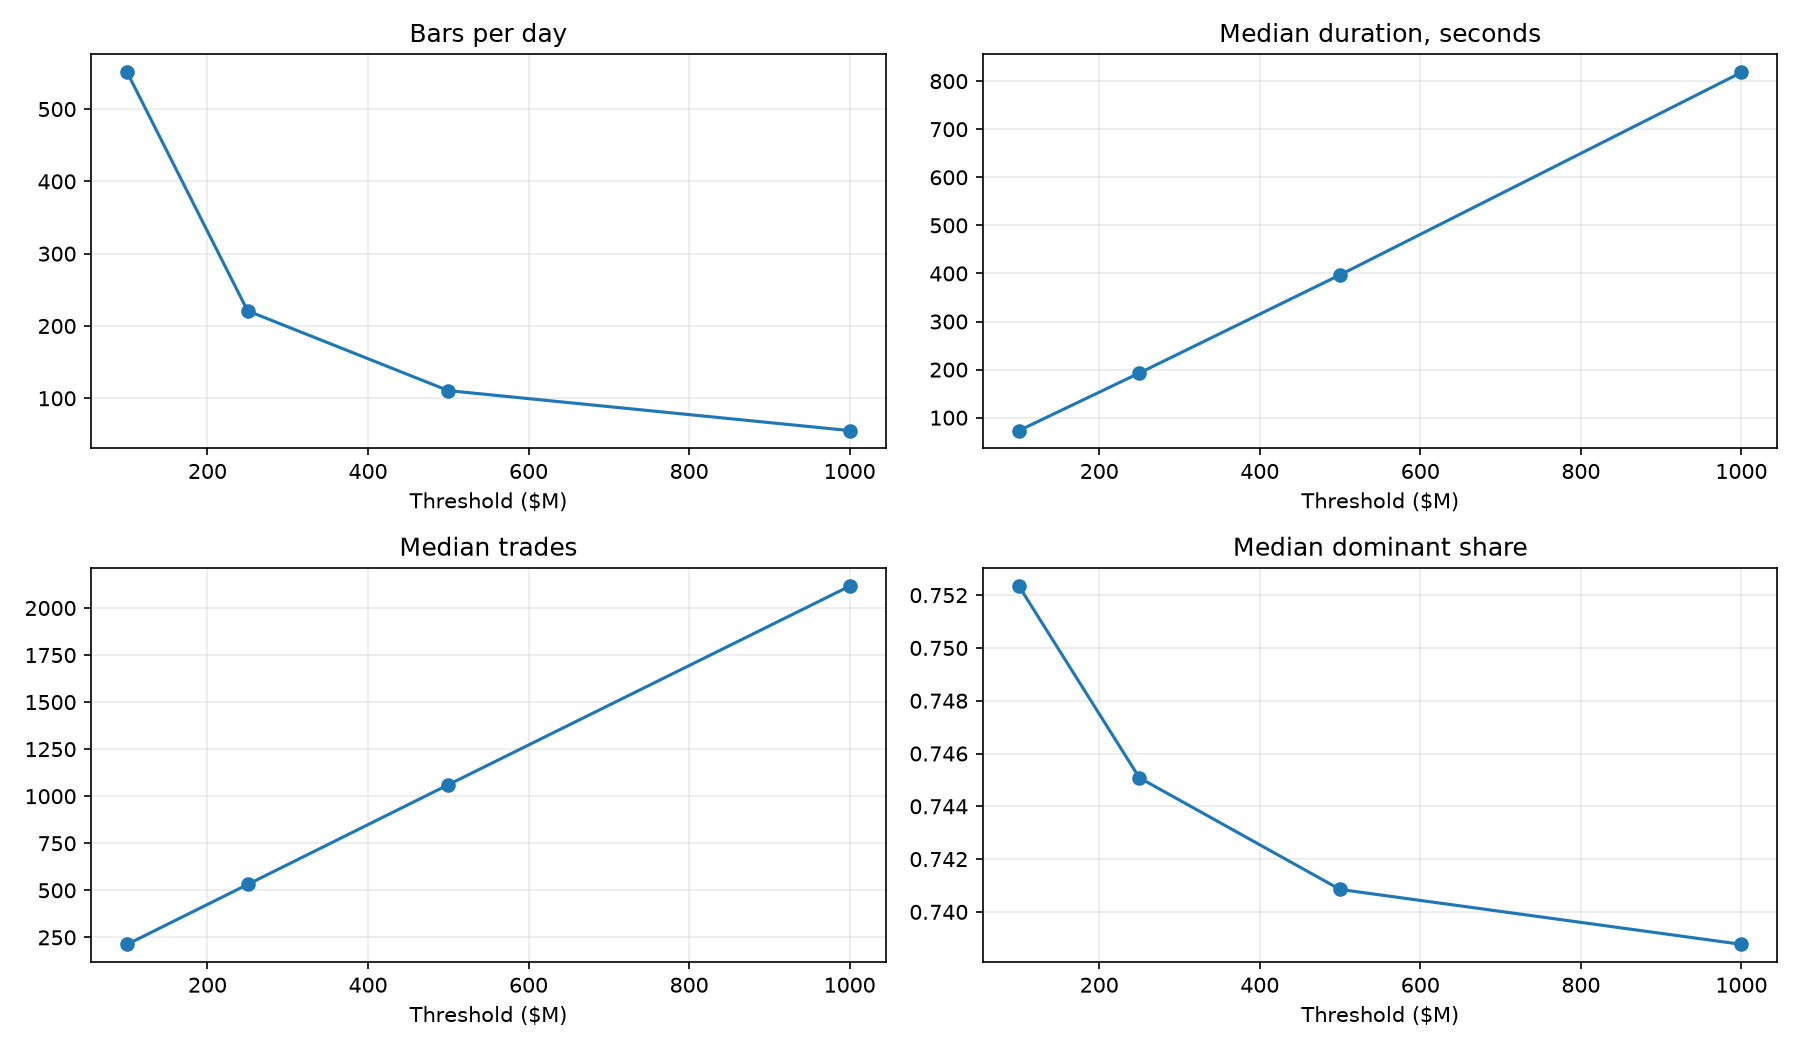

In [3]:
display(Image(filename=OUT / "plots/threshold_sensitivity.png"))

In [4]:
pd.DataFrame(summary["mbp1_availability"])

,chunks,downloaded,first_start,last_end,raw_rows,root,rows
0,30,True,2026-05-24T00:00:00Z,2026-06-23T00:00:00Z,50643841,GC,41136248
1,30,True,2026-05-24T00:00:00Z,2026-06-23T00:00:00Z,15964487,HG,14509173
2,30,True,2026-05-24T00:00:00Z,2026-06-23T00:00:00Z,3278290,PA,2585587
3,30,True,2026-05-24T00:00:00Z,2026-06-23T00:00:00Z,17536652,PL,16497576
4,30,True,2026-05-24T00:00:00Z,2026-06-23T00:00:00Z,36240697,SI,23414152


## Contribution Geometry

In [5]:
shares = pd.read_parquet(OUT / "contribution_shares.parquet")
features = pd.read_parquet(OUT / "flow_features.parquet")
anomalies = pd.read_parquet(OUT / "flow_anomalies.parquet")
bars = pd.read_parquet(OUT / "primary_bars.parquet")

mean_share = shares.mean().sort_values(ascending=False).rename("mean_notional_share")
dominant = bars["dominant_root"].value_counts(normalize=True).rename("dominant_frequency")
pd.concat([mean_share, dominant], axis=1).fillna(0.0)

,mean_notional_share,dominant_frequency
GC,0.734745,0.985010
SI,0.161532,0.009349
HG,0.078877,0.005480
PL,0.017163,0.000000
PA,0.007285,0.000161
ALI,0.000399,0.000000


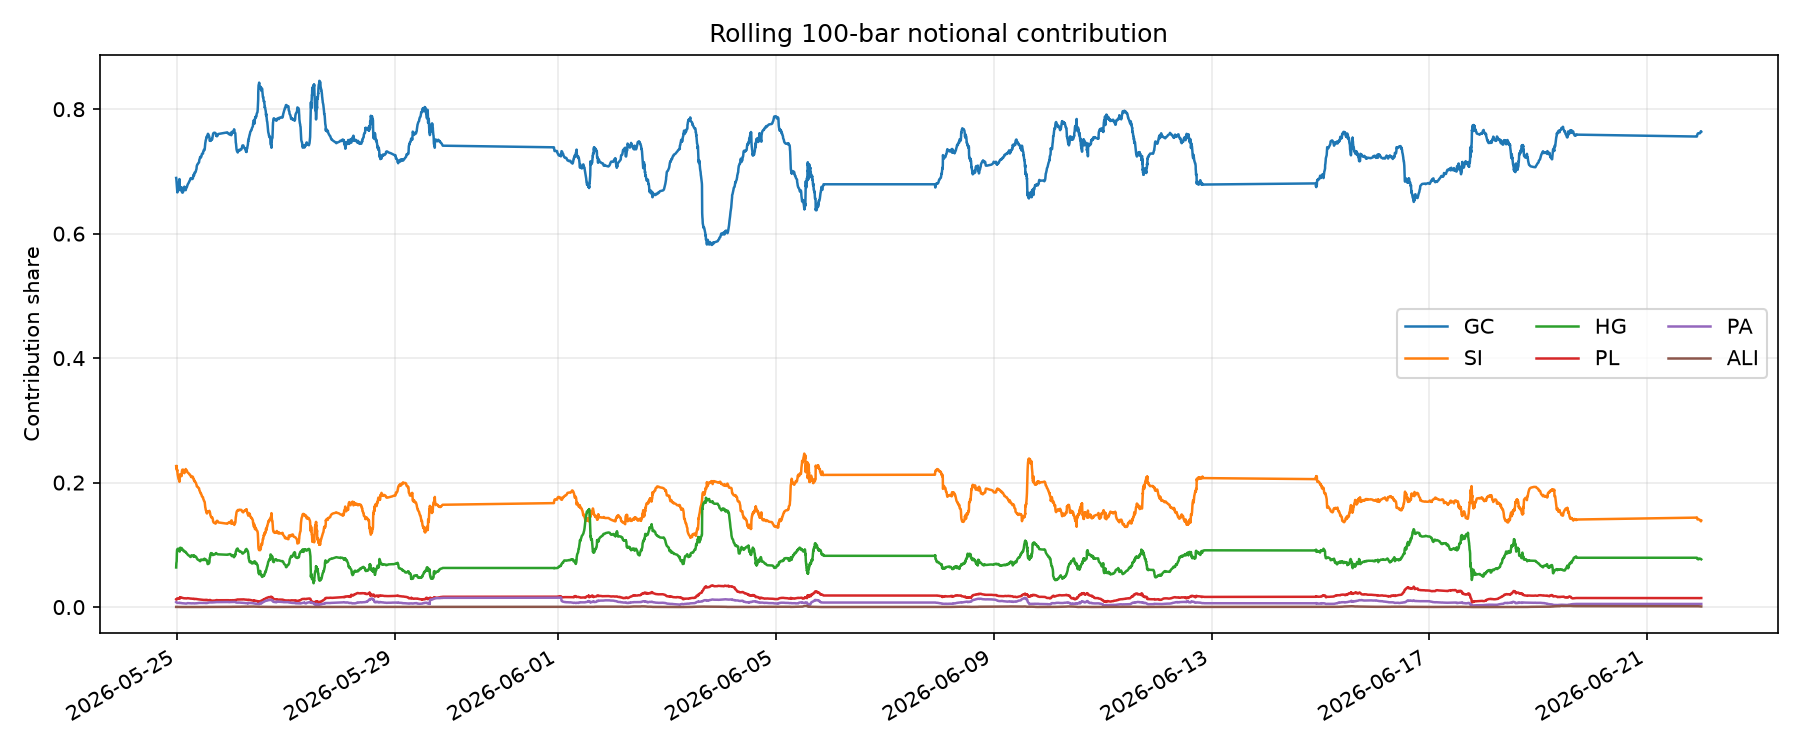

In [6]:
display(Image(filename=OUT / "plots/rolling_contribution.png"))

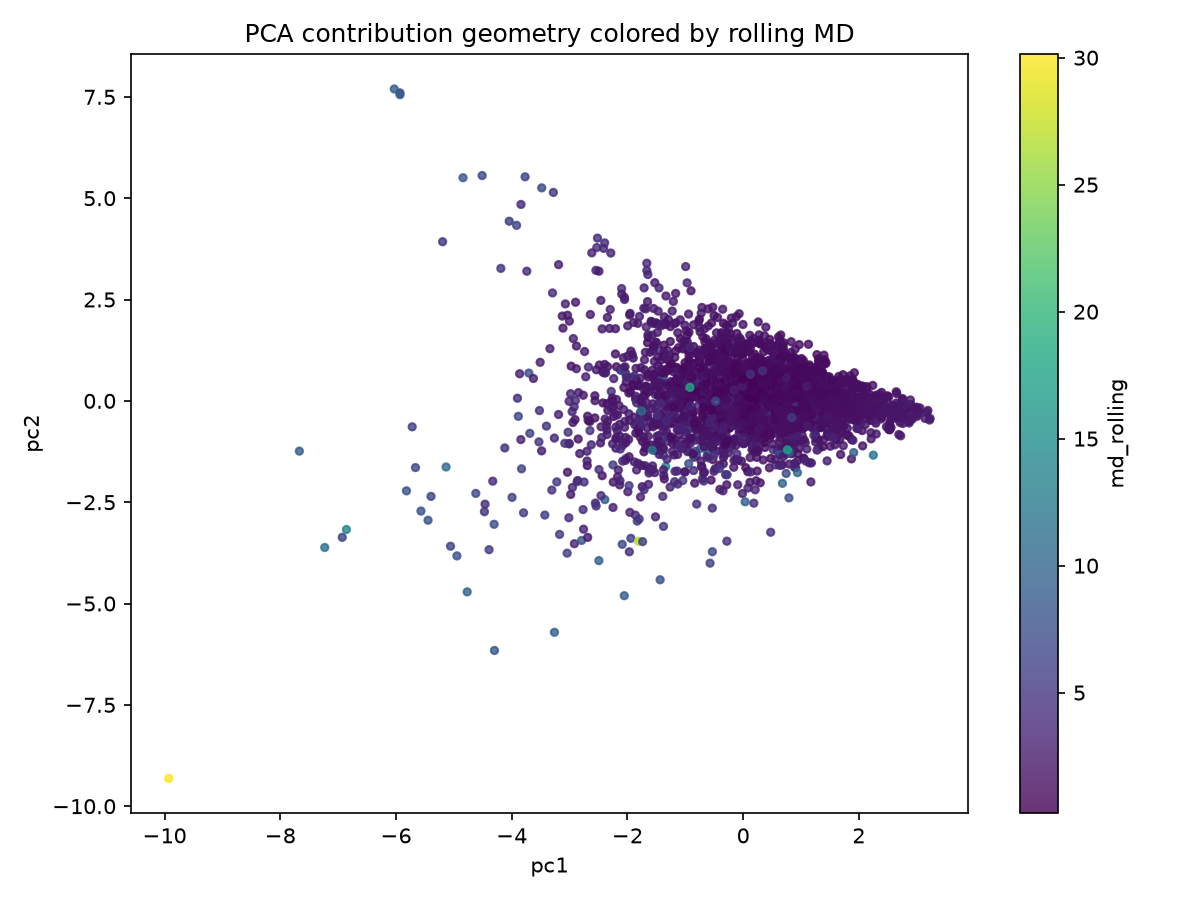

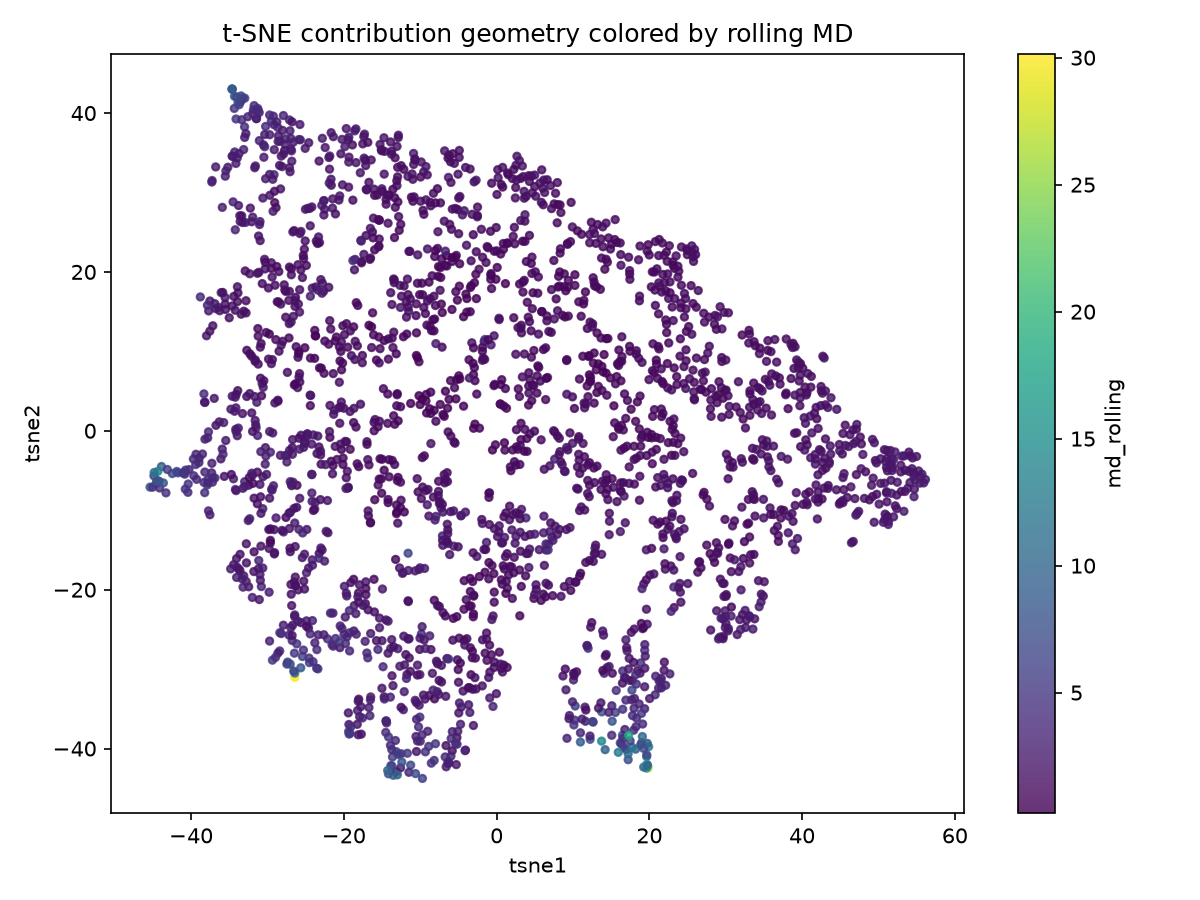

In [7]:
display(Image(filename=OUT / "plots/geometry_pca_md.png"))
if (OUT / "plots/geometry_tsne_md.png").exists():
    display(Image(filename=OUT / "plots/geometry_tsne_md.png"))

In [8]:
pd.read_csv(OUT / "geometry_pca_explained.csv")

,Unnamed: 0,explained_variance_ratio
0,pc1,0.365130
1,pc2,0.205920
2,pc3,0.165735


In [9]:
pd.read_csv(OUT / "geometry_pca_loadings.csv", index_col=0)

,pc1,pc2,pc3
GC,0.647873,-0.232094,-0.037930
SI,-0.425877,0.629012,0.018465
HG,-0.429351,-0.251666,0.072806
PL,-0.355058,-0.399226,-0.146525
PA,-0.294590,-0.549182,-0.175303
ALI,-0.041210,-0.161732,0.969907


## Concentration And Mahalanobis Anomalies

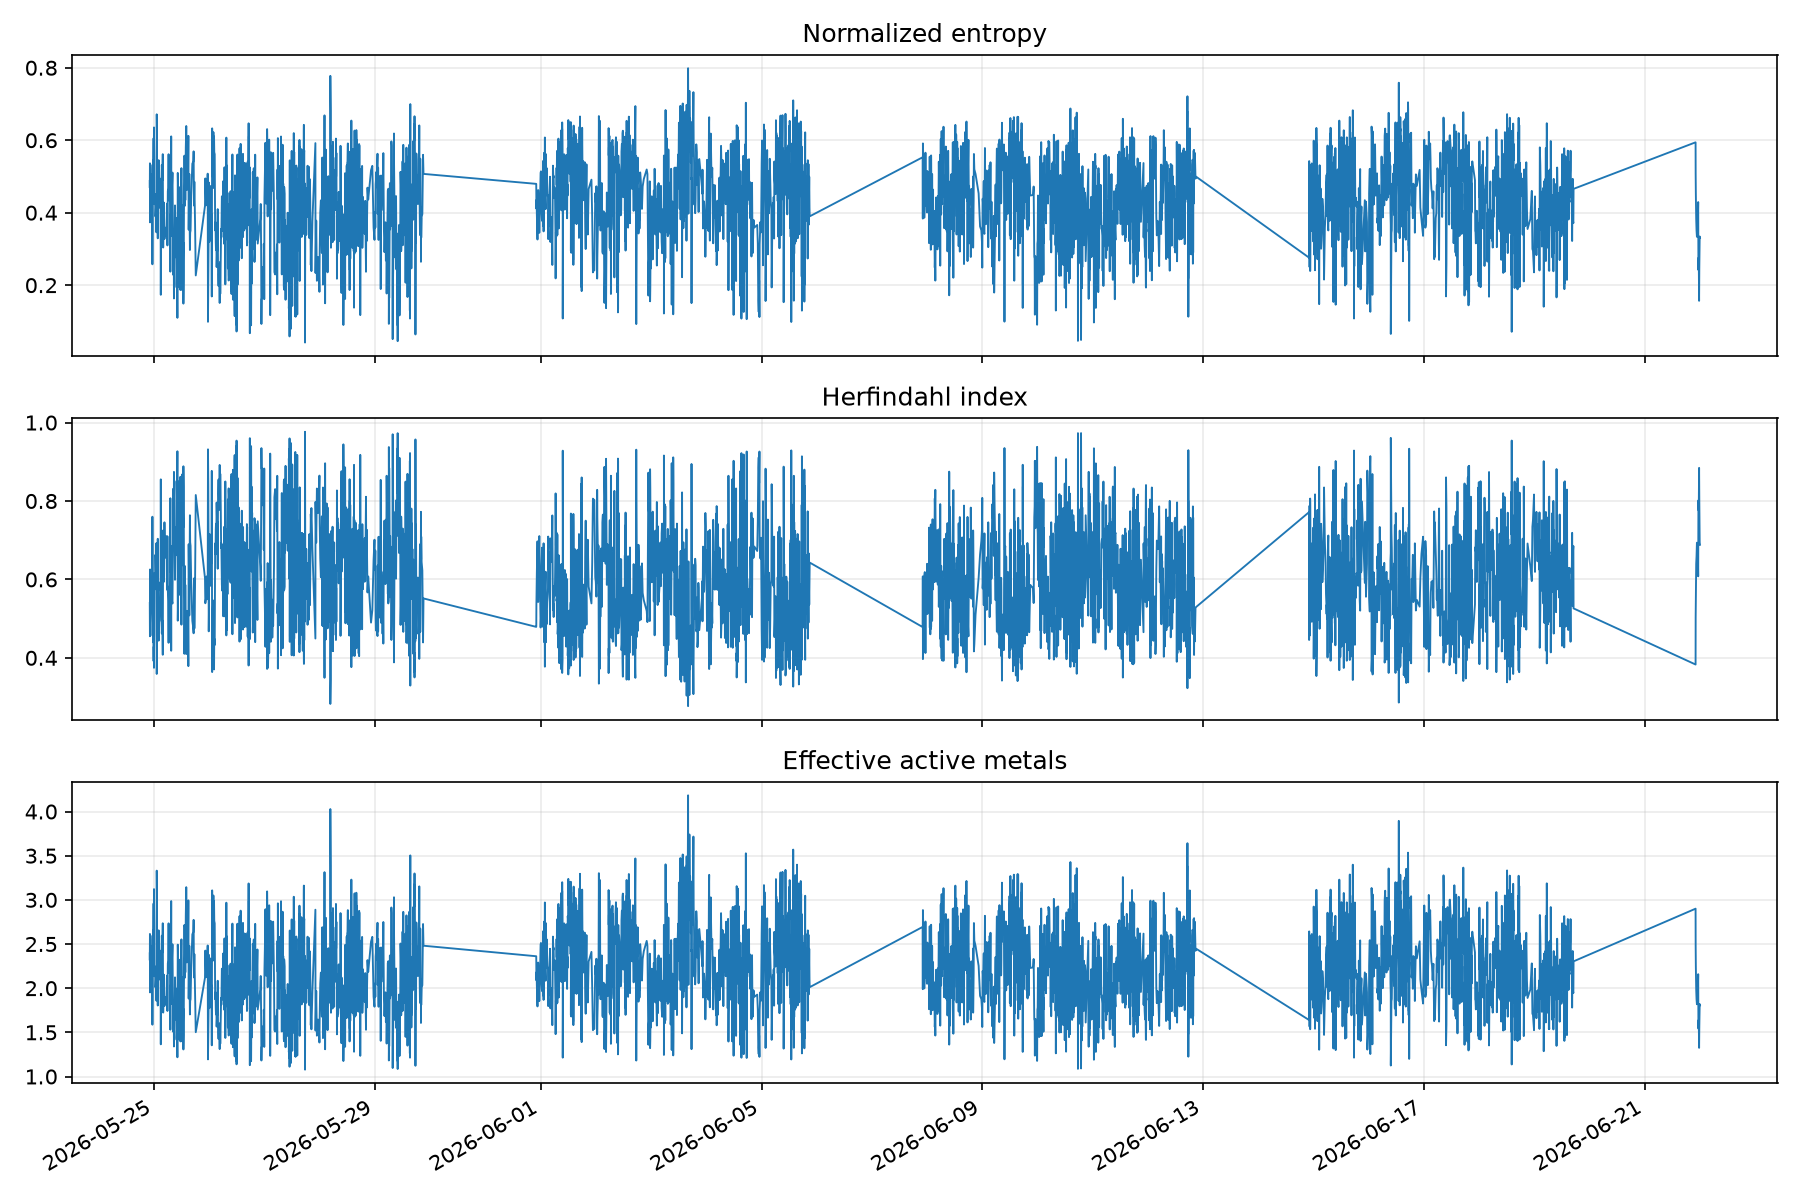

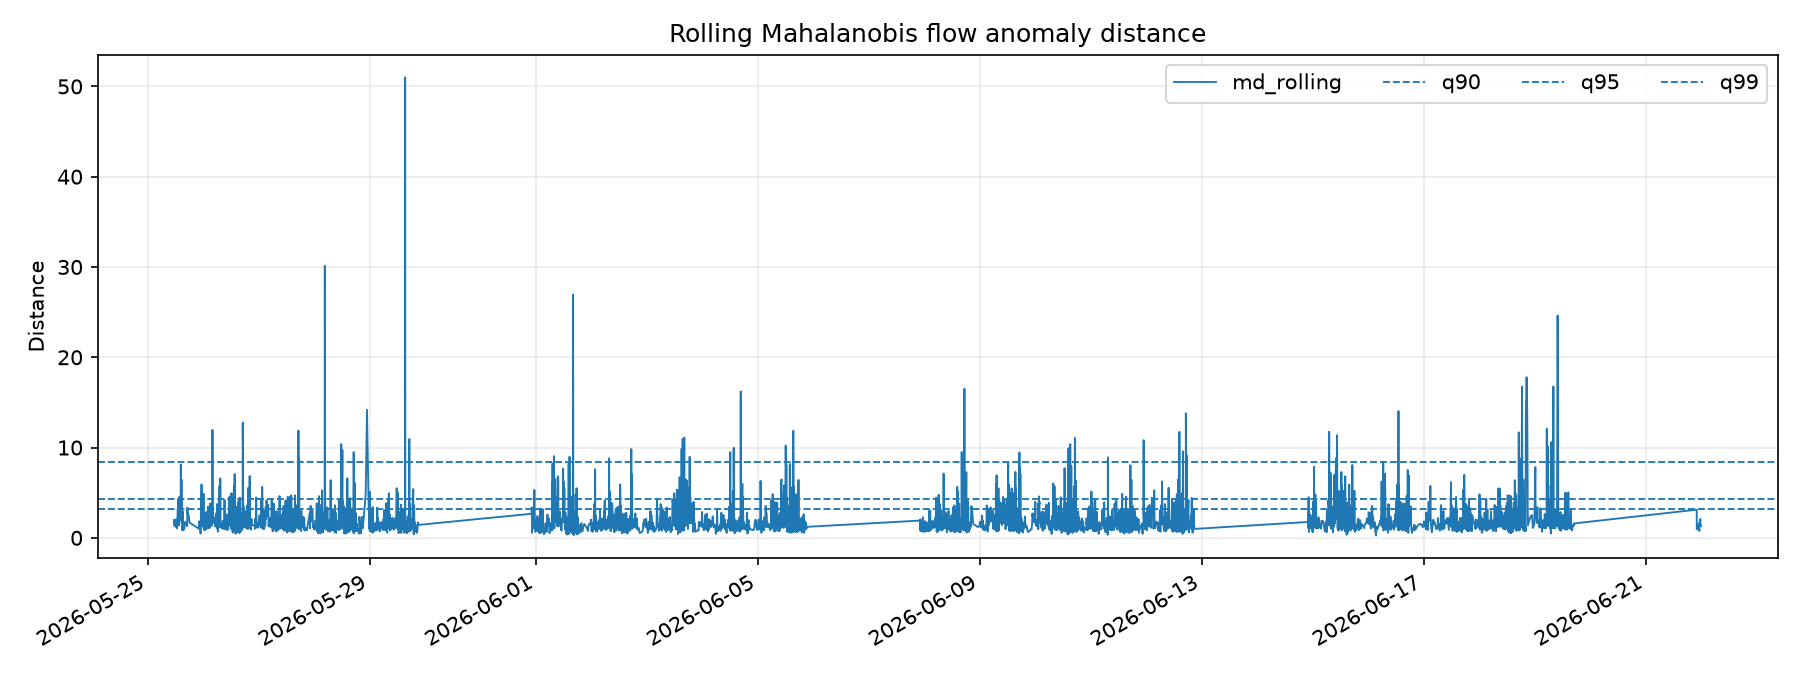

In [10]:
display(Image(filename=OUT / "plots/concentration.png"))
display(Image(filename=OUT / "plots/mahalanobis.png"))

In [11]:
anomaly_counts = {col: int(anomalies[col].sum()) for col in ["md_q90", "md_q95", "md_q99"]}
md_quantiles = anomalies["md_rolling"].quantile([0.90, 0.95, 0.99])
pd.DataFrame(
    {
        "count": anomaly_counts,
        "threshold": md_quantiles.rename(index={0.90: "md_q90", 0.95: "md_q95", 0.99: "md_q99"}),
    }
)

,count,threshold
md_q90,611,3.211441
md_q95,306,4.329065
md_q99,62,8.359664


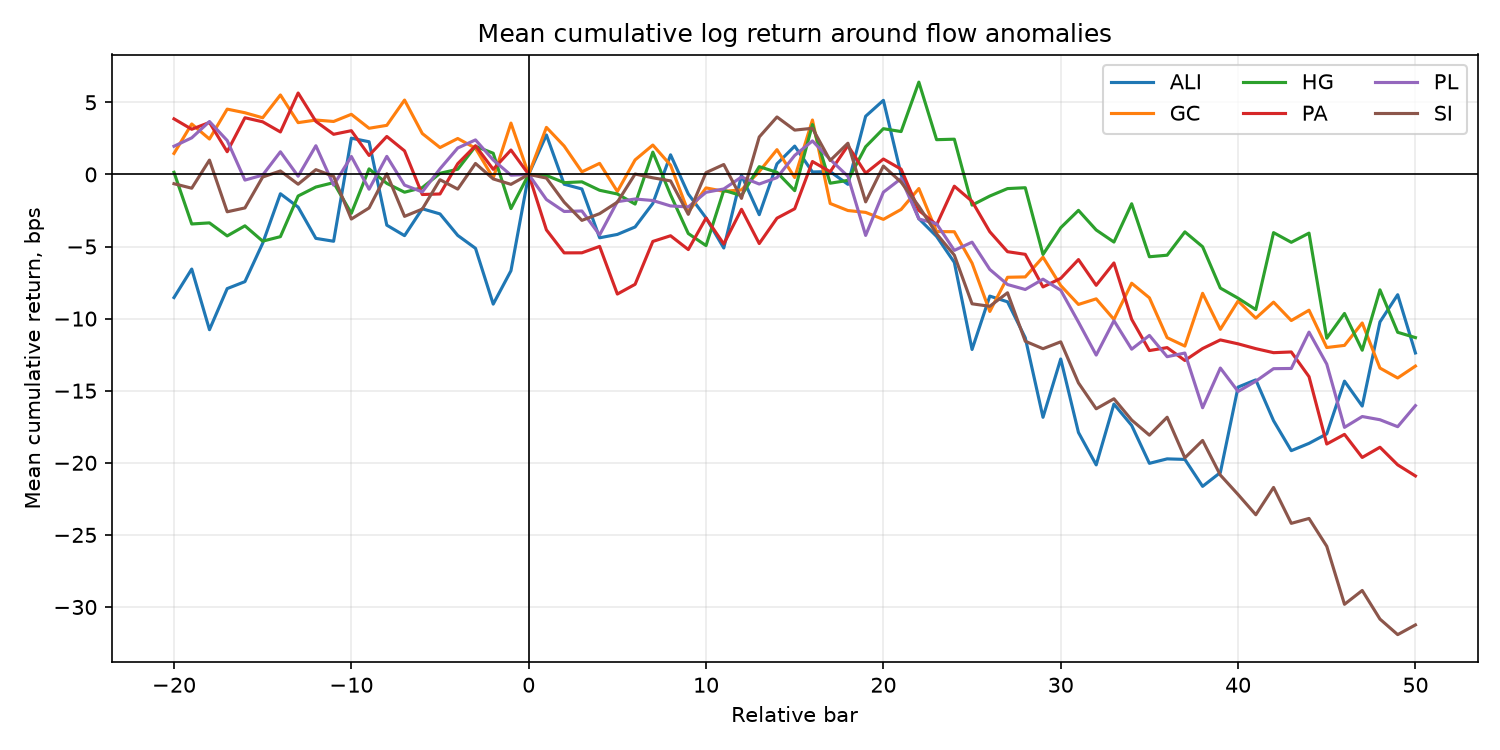

In [12]:
display(Image(filename=OUT / "plots/event_study_q95.png"))

## Trade-Size Flow Disagreement

In [13]:
trade_size_summary = pd.read_csv(OUT / "trade_size_summary.csv")
trade_size_summary.assign(
    notional_share=lambda df: df["notional"] / df.groupby("root")["notional"].transform("sum")
).head(24)

,root,size_bucket,trades,notional,median_notional,mean_notional,notional_share
0,ALI,small,2839,2.481973e+08,87400.0,8.742418e+04,0.400223
1,ALI,medium,2271,2.205402e+08,92637.5,9.711148e+04,0.355626
2,ALI,large,511,1.086523e+08,185612.5,2.126269e+05,0.175204
3,ALI,very_large,57,4.275702e+07,473937.5,7.501231e+05,0.068947
4,GC,small,978291,4.191118e+11,431050.0,4.284122e+05,0.366949
5,GC,medium,782506,4.278690e+11,453570.0,5.467933e+05,0.374616
6,GC,large,175976,2.193817e+11,1272510.0,1.246657e+06,0.192077
7,GC,very_large,19563,7.579032e+10,3044580.0,3.874167e+06,0.066357
8,HG,small,239575,3.819052e+10,159725.0,1.594094e+05,0.311605
9,HG,medium,190623,4.743384e+10,309350.0,2.488359e+05,0.387024


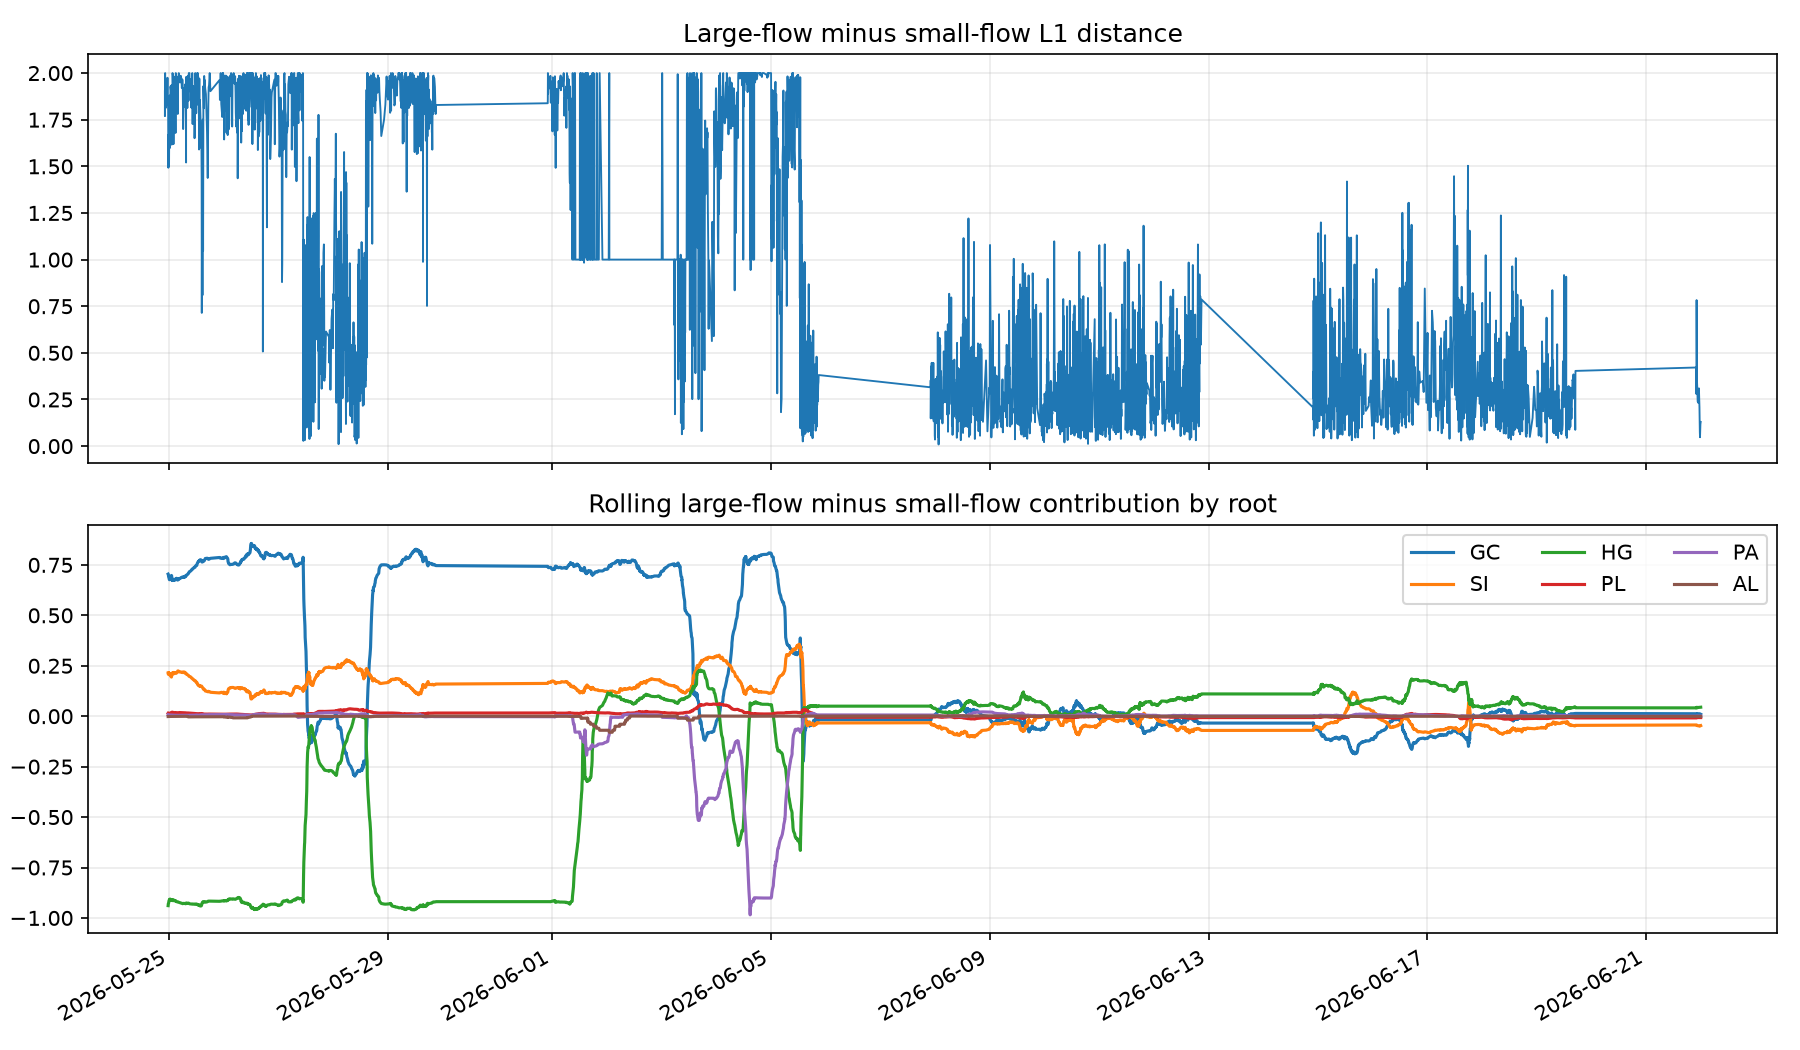

In [14]:
display(Image(filename=OUT / "plots/trade_size_disagreement.png"))

In [15]:
disagreement = pd.read_parquet(OUT / "trade_size_disagreement.parquet")
disagreement.describe().T

,count,mean,std,min,25%,50%,75%,max
GC_large_minus_small_share,6204.0,0.212332,0.410802,-0.784860,-0.079157,0.071876,0.657932,1.000000
SI_large_minus_small_share,6204.0,0.056248,0.162170,-0.332143,-0.068743,0.041479,0.143923,0.874890
HG_large_minus_small_share,6204.0,-0.151357,0.411374,-1.000000,-0.076379,0.006877,0.077835,0.927110
PL_large_minus_small_share,6204.0,0.006253,0.025407,-0.077552,-0.008270,0.002800,0.014319,0.293444
PA_large_minus_small_share,6204.0,-0.042348,0.196710,-1.000000,-0.004475,0.000000,0.006514,0.230525
ALI_large_minus_small_share,6204.0,-0.001985,0.042357,-1.000000,0.000000,0.000000,0.000000,0.076179
large_small_l1_distance,6204.0,0.806165,0.683697,0.008846,0.243609,0.481541,1.462062,2.000000
very_large_small_l1_distance,6204.0,0.971216,0.661242,0.000000,0.395497,0.850474,1.624004,2.000000


## Relative Value And Cointegration

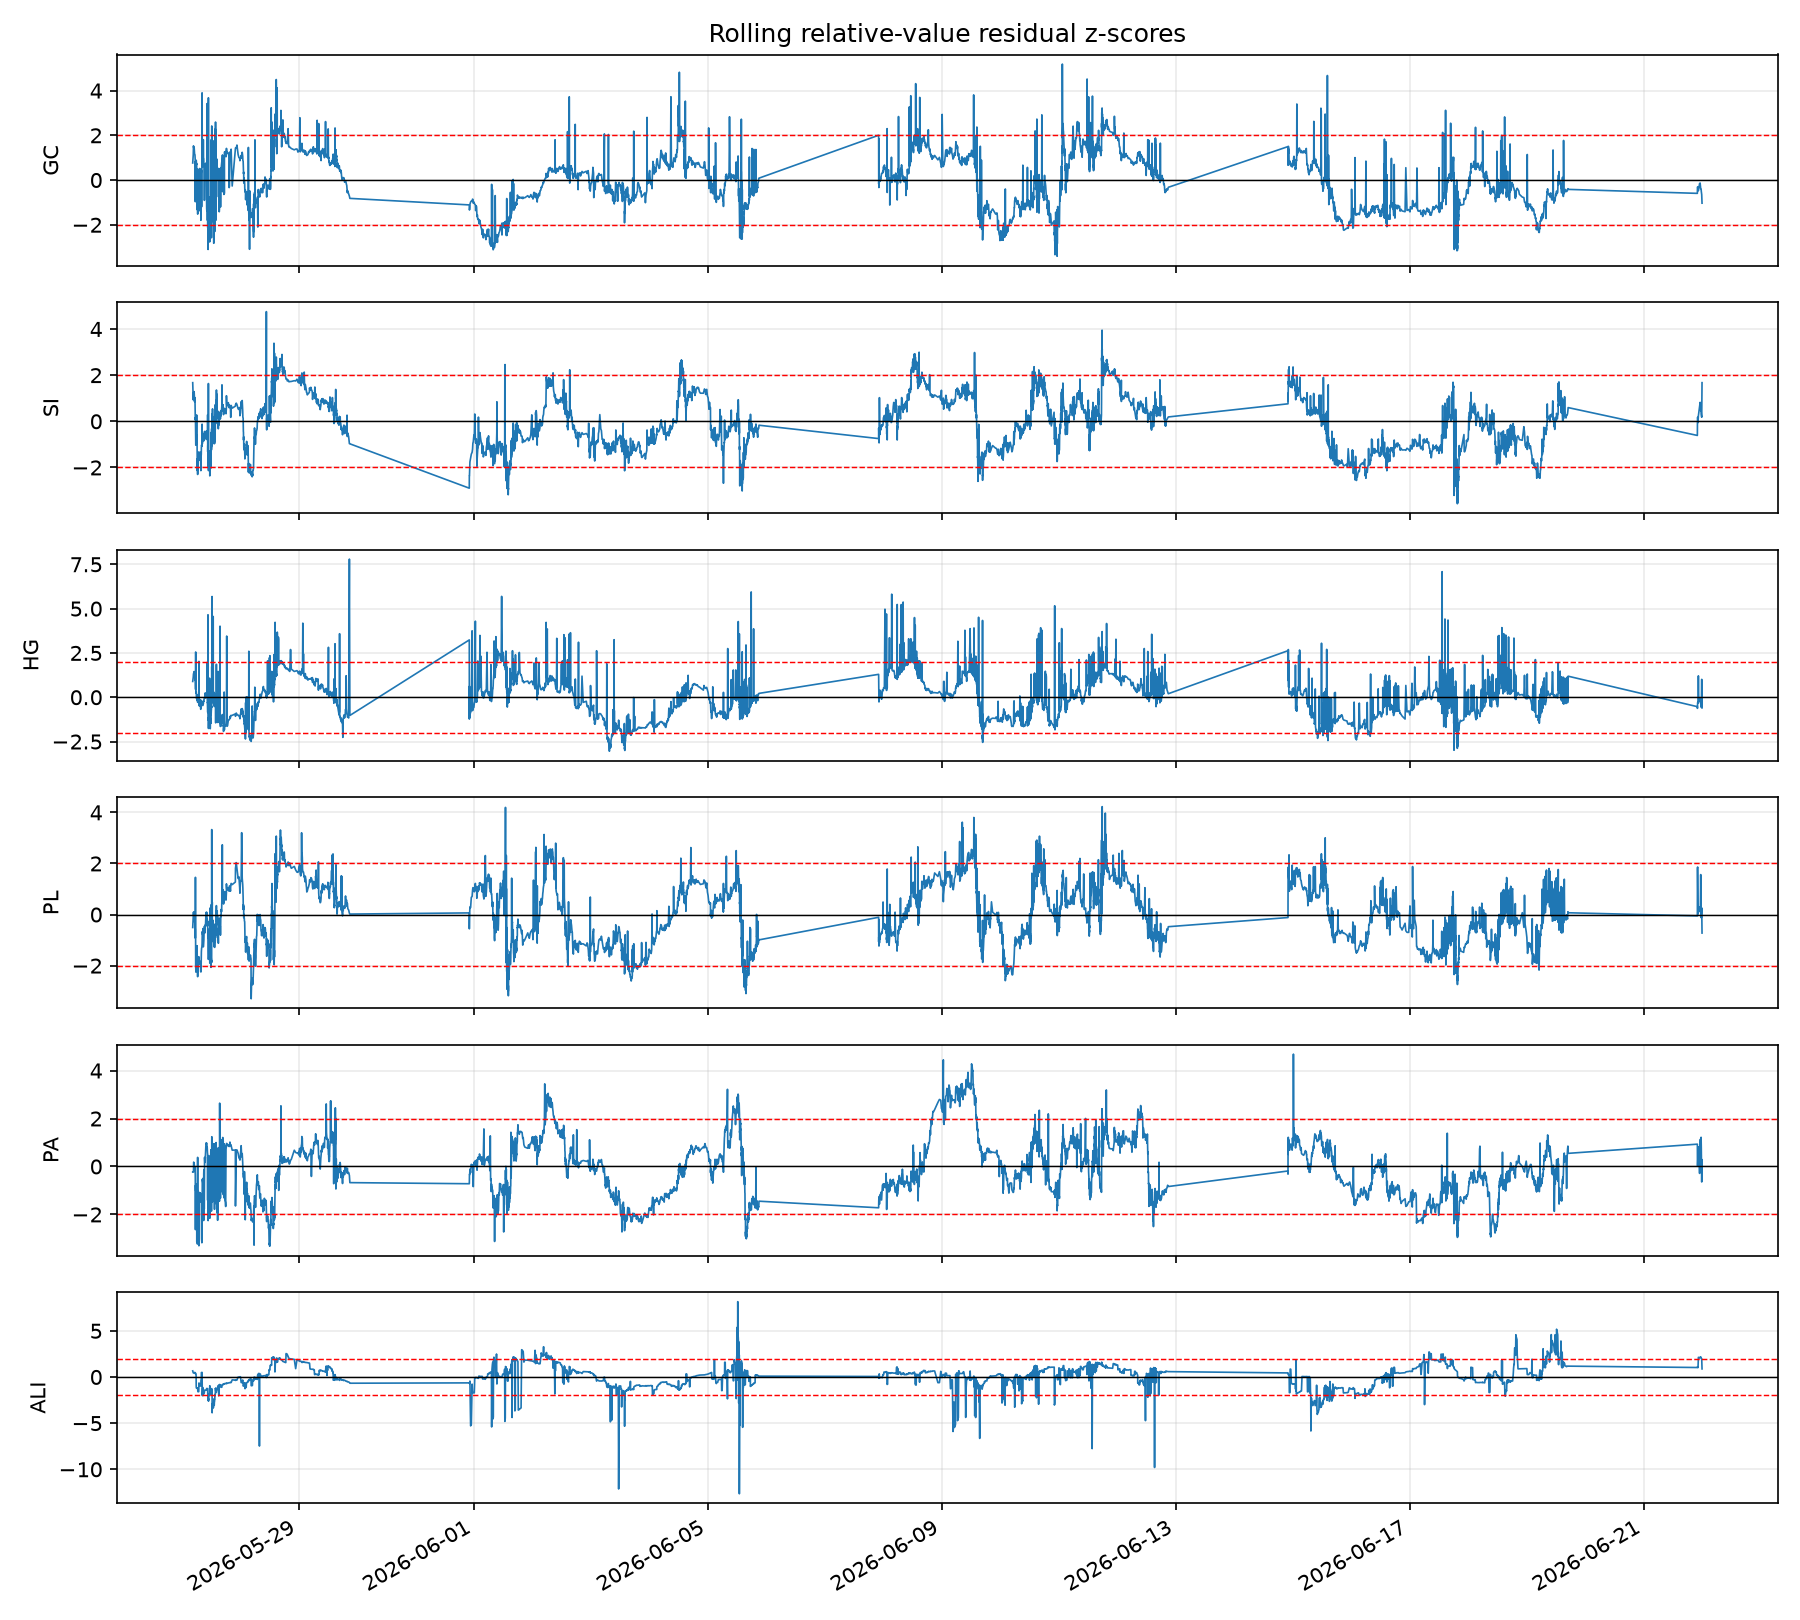

In [16]:
display(Image(filename=OUT / "plots/fair_value_zscores.png"))

In [17]:
cointegration = pd.read_csv(OUT / "cointegration.csv")
cointegration.sort_values("coint_pvalue").head(15)

,root_a,root_b,observations,coint_tstat,coint_pvalue,hedge_beta_a_on_b,spread_adf_tstat,spread_adf_pvalue,half_life_bars
6,SI,PL,6204,-3.652241,0.021081,1.087091,-3.651996,0.004841,8.697707
2,GC,PL,6204,-2.702271,0.198763,0.550174,-2.702061,0.073682,6.748534
0,GC,SI,6204,-2.451041,0.301078,0.498929,-2.450895,0.127884,7.219417
13,PL,ALI,6193,-2.282542,0.382296,1.149258,-2.282631,0.177631,38.431167
10,HG,PA,6204,-2.179116,0.435158,0.189456,-2.178949,0.213974,8.549630
9,HG,PL,6204,-2.132154,0.459575,0.150360,-2.132031,0.231831,9.250750
7,SI,PA,6204,-2.115161,0.468445,1.134376,-2.116412,0.237966,40.804033
11,HG,ALI,6193,-2.056879,0.498914,0.130090,-2.056689,0.262283,11.548086
8,SI,ALI,6193,-1.991869,0.532802,1.146897,-1.994179,0.289131,55.381670
4,GC,ALI,6193,-1.903257,0.578354,0.637298,-1.903732,0.330308,28.502462


## Forward Return Studies

In [18]:
forward = pd.read_csv(OUT / "forward_studies.csv")
forward.sort_values("tstat", ascending=False).head(25)

,feature,root,horizon,bucket,bucket_type,observations,mean_bps,median_bps,vol_bps,tstat,hit_rate,sharpe_per_event,baseline_mean_bps,excess_mean_bps
1789,large_small_l1_distance,ALI,20,10,decile,621,11.289936,2.050231,77.101858,3.648988,0.520129,0.146429,NaN,NaN
21,md_rolling,GC,5,2,decile,610,4.941113,1.361138,44.992152,2.712395,0.527869,0.109822,NaN,NaN
244,md_rolling,PA,1,5,decile,610,4.876065,0.000000,44.538813,2.703932,0.429508,0.109479,NaN,NaN
1088,distance_from_equal_weight,GC,1,9,decile,620,3.644752,0.888624,33.613466,2.699917,0.525806,0.108431,NaN,NaN
728,hhi,GC,1,9,decile,620,3.644752,0.888624,33.613466,2.699917,0.525806,0.108431,NaN,NaN
1406,distance_from_equal_weight,ALI,5,7,decile,621,10.368276,0.000000,96.345955,2.681754,0.314010,0.107615,NaN,NaN
1046,hhi,ALI,5,7,decile,621,10.368276,0.000000,96.345955,2.681754,0.314010,0.107615,NaN,NaN
1796,large_small_l1_distance,ALI,50,7,decile,620,11.212652,11.810454,105.089669,2.656710,0.587097,0.106696,NaN,NaN
1618,large_small_l1_distance,HG,50,9,decile,620,7.796676,-1.947842,75.887950,2.558188,0.485484,0.102739,NaN,NaN
1058,hhi,ALI,10,9,decile,620,10.135146,0.000000,103.631643,2.435193,0.430645,0.097800,NaN,NaN


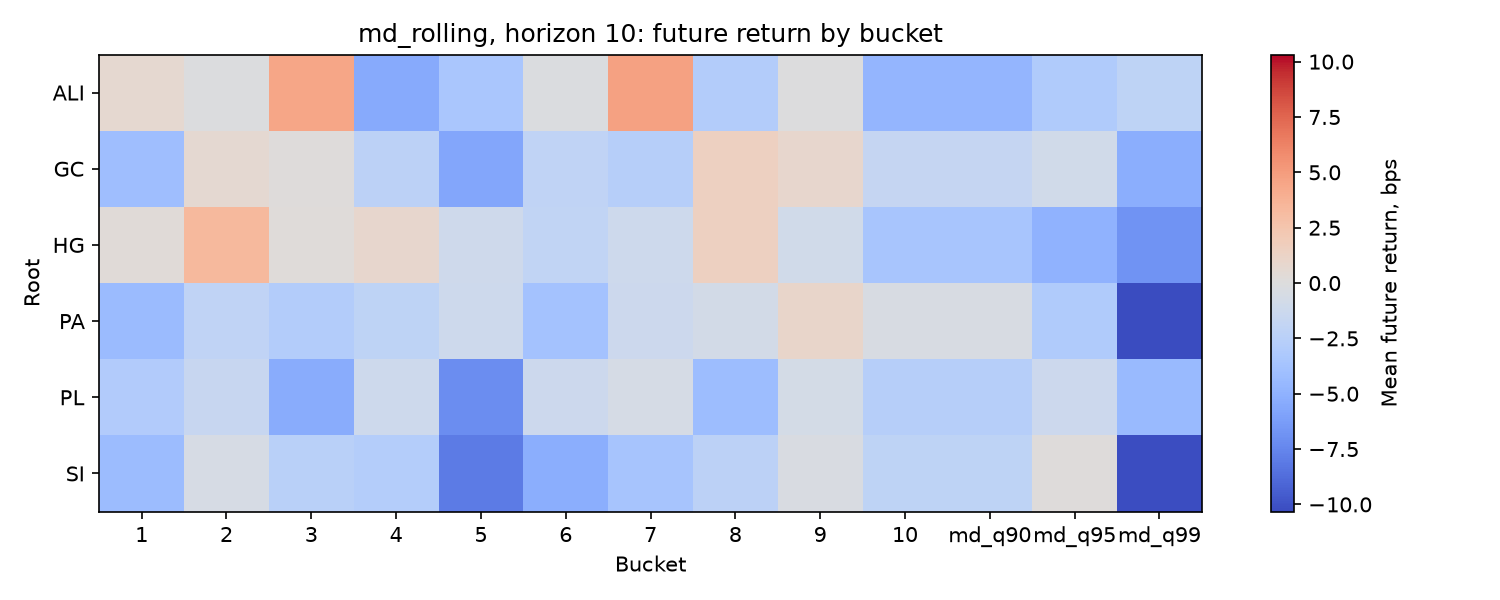

In [19]:
display(Image(filename=OUT / "plots/forward_md_rolling_h10.png"))

In [20]:
ic = pd.read_csv(OUT / "information_coefficients.csv")
ic.assign(abs_ic=ic["spearman_ic"].abs()).sort_values("abs_ic", ascending=False).head(30)

,feature,root,horizon,spearman_ic,pvalue,observations,abs_ic
2075,HG_large_minus_small_share,PL,50,-0.106908,4.134195e-17,6154,0.106908
2081,HG_large_minus_small_share,PA,50,-0.087621,5.757261e-12,6154,0.087621
2015,GC_large_minus_small_share,ALI,50,0.087525,6.073323e-12,6154,0.087525
2195,ALI_large_minus_small_share,ALI,50,-0.072811,1.076198e-08,6154,0.072811
2069,HG_large_minus_small_share,HG,50,-0.069196,5.521188e-08,6154,0.069196
1140,complex_signed_notional_ratio,PA,1,0.065078,2.899154e-07,6203,0.065078
2003,GC_large_minus_small_share,PL,50,0.062695,8.562908e-07,6154,0.062695
1248,GC_signed_notional_share,PA,1,0.061980,1.033130e-06,6203,0.061980
2194,ALI_large_minus_small_share,ALI,20,-0.060729,1.761289e-06,6184,0.060729
2117,PL_large_minus_small_share,PA,50,-0.059499,3.001540e-06,6154,0.059499


## Momentum Versus Mean Reversion Classification

In [21]:
classification = pd.read_csv(OUT / "signal_classification.csv")
classification.groupby(["mechanism", "horizon"]).size().unstack(fill_value=0)

horizon,1,2,5,10,20,50
mechanism,,,,,,
mean_reversion,81,63,67,64,66,82
momentum,75,93,89,92,90,74


In [22]:
classification.assign(abs_t=classification["tstat"].abs()).sort_values(
    "abs_t", ascending=False
).head(30)

,signal,root,horizon,mechanism,beta,tstat,correlation,sign_agreement,observations,abs_t
934,rv_z_ALI,ALI,20,mean_reversion,-0.003118,-29.349985,-0.363109,0.440254,5674,29.349985
933,rv_z_ALI,ALI,10,mean_reversion,-0.002854,-28.830885,-0.357240,0.373153,5684,28.830885
932,rv_z_ALI,ALI,5,mean_reversion,-0.002230,-25.546185,-0.320845,0.292143,5689,25.546185
804,rv_z_HG,HG,1,mean_reversion,-0.001384,-25.497954,-0.320200,0.447743,5693,25.497954
805,rv_z_HG,HG,2,mean_reversion,-0.001366,-24.824445,-0.312604,0.454322,5692,24.824445
806,rv_z_HG,HG,5,mean_reversion,-0.001377,-24.027703,-0.303581,0.457022,5689,24.027703
935,rv_z_ALI,ALI,50,mean_reversion,-0.002804,-23.555960,-0.299236,0.466159,5644,23.555960
807,rv_z_HG,HG,10,mean_reversion,-0.001392,-22.576376,-0.286913,0.449156,5684,22.576376
931,rv_z_ALI,ALI,2,mean_reversion,-0.001535,-21.360297,-0.272459,0.174982,5692,21.360297
808,rv_z_HG,HG,20,mean_reversion,-0.001293,-19.167991,-0.246649,0.470215,5674,19.167991


## First-Pass Research Conclusions

These diagnostics are not yet a trading strategy. Treat them as a ranking and triage layer:

- GC dominates cross-sectional dollar-bar notional, so anomaly definitions are mostly detecting deviations from a GC-heavy baseline rather than equal-weight metal participation.
- High Mahalanobis readings identify distorted flow composition, but the unconditional q95/q99 event studies need root-specific validation before they can be converted into trades.
- The strongest first-pass information coefficients are concentrated in trade-size disagreement features, especially large-minus-small HG and GC contribution shares at longer bar horizons.
- Cointegration is weak over this 30-day bar sample; relative-value convergence should be tested with longer 1-minute history before being used as the primary mechanism.
- MBP-1 data is available for `GC`, `SI`, `HG`, `PL`, `PA` over the 30-day window; `ALI` remains trade-only in the current MBP-1 pull.